## 07 Final Model: Integration & Evaluation

Integrates all components of the physical framework into a complete pipeline and evaluates its performance against a baseline model (Logistic Regression).

In [11]:
import os
import sqlite3
import sys
import warnings
import pandas as pd
import matplotlib.pyplot as plt
%matplotlib inline
from sklearn.ensemble import GradientBoostingClassifier, RandomForestClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import roc_auc_score, roc_curve
from sklearn.model_selection import StratifiedKFold, cross_val_score, train_test_split
from sklearn.preprocessing import StandardScaler

warnings.filterwarnings('ignore')

ROOT = os.path.abspath(os.path.join(os.path.dirname(os.path.abspath('__file__')), '..'))
sys.path.insert(0, ROOT)
os.chdir(os.path.join(ROOT, 'notebooks'))

from src.visualization import PALETTE, set_style 

set_style()

try:
    LIFELINES_OK = True
except Exception:
    LIFELINES_OK = False

DATA_DIR = os.path.join(ROOT, 'data')
df_clean = pd.read_csv(os.path.join(DATA_DIR, 'telco_clean.csv'))
df_features = pd.read_csv(os.path.join(DATA_DIR, 'telco_features.csv'))
df_final = pd.read_csv(os.path.join(DATA_DIR, 'telco_final.csv'))
df = df_features.copy()
df_model = pd.get_dummies(df, columns=['Contract','PaymentMethod','InternetService'], drop_first=True)

conn = sqlite3.connect(':memory:')
df.to_sql('telco', conn, if_exists='replace', index=False)
df_clean.to_sql('telco_clean', conn, if_exists='replace', index=False)

print(f'Ready: {len(df):,} customers | churn rate {df.Churn_bin.mean():.1%}')


Ready: 7,043 customers | churn rate 26.5%


### Features for the final model

In [12]:
# Physical model features
physical_features = ['E0', 'E_eq', 'gamma', 'tau', 'estimated_perturbation', 'num_services_protective', 'num_services_entertainment', 'is_internet_no', 'is_internet_dsl', 'is_internet_fiber']

# Features baseline 
features_baseline = ['tenure', 'MonthlyCharges', 'TotalCharges', 'num_services_protective', 'num_services_entertainment']

# One-hot encoded categorical variables
df_model = pd.get_dummies(df, columns=['Contract', 'PaymentMethod', 'InternetService'], drop_first=True)

new_categorical_features = [c for c in df_model.columns if c.startswith(('Contract_','PaymentMethod_','InternetService_'))]
features_complete = physical_features + features_baseline + new_categorical_features
features_complete = list(set(features_complete))  # deduplicate

X_physical = df_model[physical_features].fillna(0)
X_baseline = df_model[features_baseline].fillna(0)
X_complete = df_model[features_complete].fillna(0)
y = df_model['Churn_bin']

print(f'Physical features: {len(physical_features)}')
print(f'Baseline features: {len(features_baseline)}')
print(f'Full features: {len(features_complete)}')

Physical features: 10
Baseline features: 5
Full features: 20


### Model Comparison with Cross-Validation

In [13]:
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
scaler = StandardScaler()

models = {
    'Baseline LR': (LogisticRegression(max_iter=1000), X_baseline),
    'Physical LR': (LogisticRegression(max_iter=1000), X_physical),
    'Physical + Full GBM': (GradientBoostingClassifier(n_estimators=100, random_state=42), X_complete),
    'Random Forest': (RandomForestClassifier(n_estimators=100, random_state=42), X_complete),}

results = {}
for name, (model, X) in models.items():
    X_scaled = scaler.fit_transform(X)
    scores = cross_val_score(model, X_scaled, y, cv=cv, scoring='roc_auc')
    results[name] = {'mean': scores.mean(), 'std': scores.std(), 'scores': scores}
    print(f'{name:35s} AUC = {scores.mean():.4f} ± {scores.std():.4f}')

Baseline LR                         AUC = 0.8215 ± 0.0155
Physical LR                         AUC = 0.8449 ± 0.0088
Physical + Full GBM                 AUC = 0.8426 ± 0.0095
Random Forest                       AUC = 0.8168 ± 0.0086


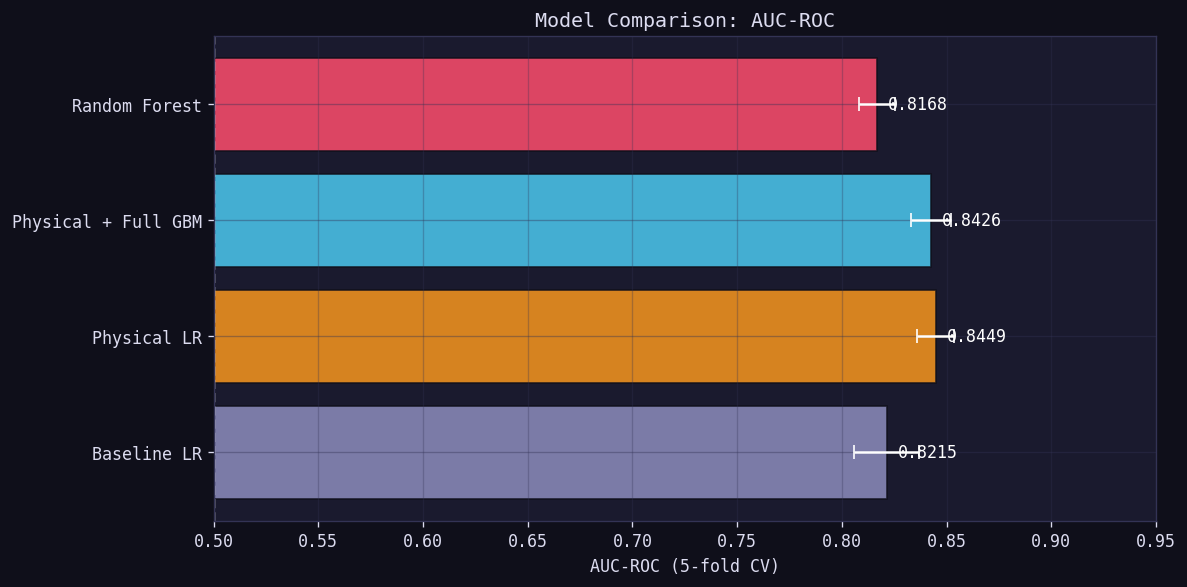

In [14]:
fig, ax = plt.subplots(figsize=(10,5))

names = list(results.keys())
means = [results[n]['mean'] for n in names]
stds = [results[n]['std'] for n in names]
colors_bar = [PALETTE['neutral'], PALETTE['accent'], PALETTE['no_churn'], PALETTE['churn']]

bars = ax.barh(names, means, xerr=stds, color=colors_bar, alpha=0.85, error_kw=dict(ecolor='white', capsize=4, linewidth=1.5), edgecolor='#0f0f1a')
for bar, val in zip(bars, means):
    ax.text(val + 0.005, bar.get_y()+bar.get_height()/2, f'{val:.4f}', va='center', ha='left', fontsize=10, color='white')

ax.set_xlabel('AUC-ROC (5-fold CV)')
ax.set_title('Model Comparison: AUC-ROC')
ax.set_xlim(0.5, 0.95)
ax.axvline(0.5, color='white', linestyle='--', alpha=0.3)
ax.grid(axis='x', alpha=0.3)

plt.tight_layout()
plt.savefig(os.path.join(ROOT, 'plots', '07_model_comparison.png'), dpi=150, bbox_inches='tight', facecolor='#0f0f1a')
plt.show()

### ROC Curves

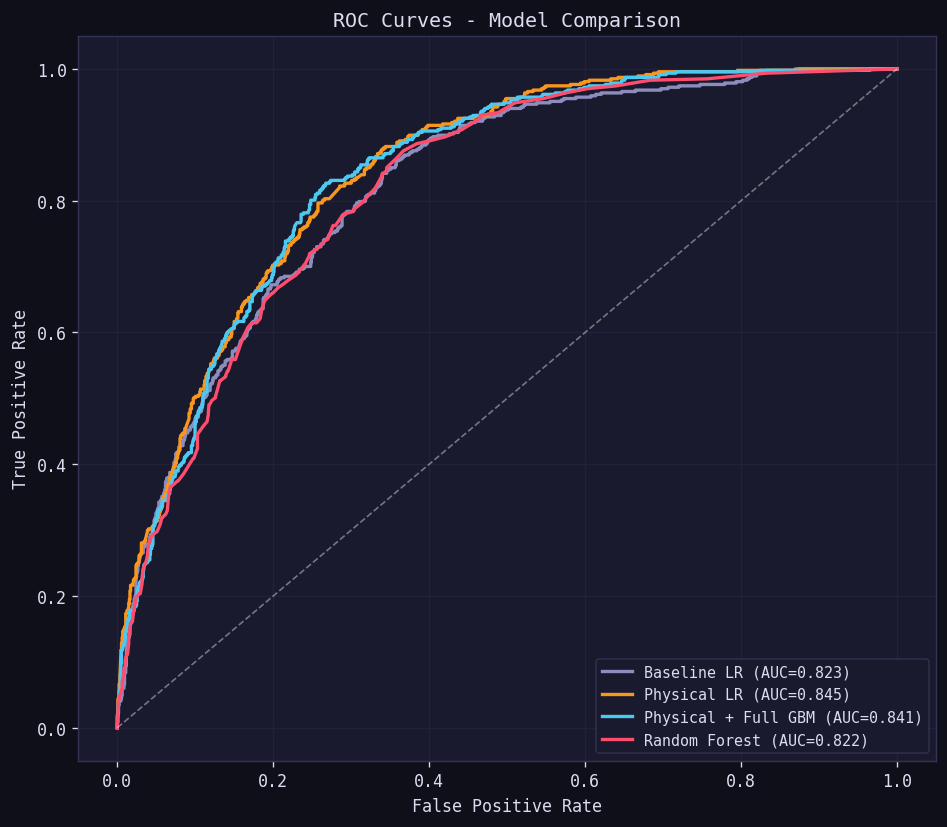

In [15]:
fig, ax = plt.subplots(figsize=(8,7))

colors_roc = [PALETTE['neutral'], PALETTE['accent'], PALETTE['no_churn'], PALETTE['churn']]

for (name, (model, X)), color in zip(models.items(), colors_roc):
    X_scaled = scaler.fit_transform(X)
    X_tr, X_te, y_tr, y_te = train_test_split(X_scaled, y, test_size=0.25, random_state=42, stratify=y)
    model.fit(X_tr, y_tr)
    prob = model.predict_proba(X_te)[:,1]
    fpr, tpr, _ = roc_curve(y_te, prob)
    auc = roc_auc_score(y_te, prob)
    ax.plot(fpr, tpr, color=color, linewidth=2, label=f'{name} (AUC={auc:.3f})')

ax.plot([0,1],[0,1], 'w--', alpha=0.4, linewidth=1)
ax.set_xlabel('False Positive Rate')
ax.set_ylabel('True Positive Rate')
ax.set_title('ROC Curves - Model Comparison')
ax.legend(fontsize=9)
ax.grid(alpha=0.3)
plt.tight_layout()
plt.savefig(os.path.join(ROOT, 'plots', '07_roc_curves.png'), dpi=150, bbox_inches='tight', facecolor='#0f0f1a')
plt.show()

### Physical Feature Importance

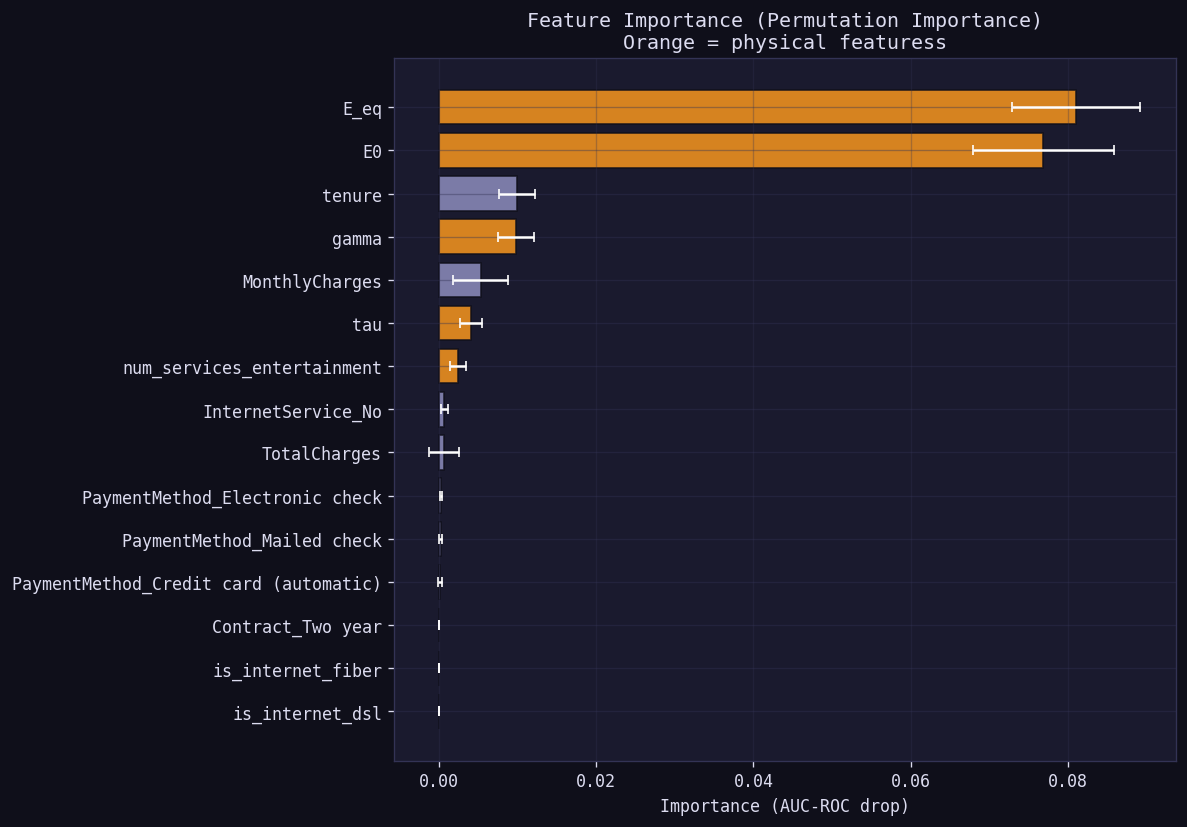

In [16]:
from sklearn.inspection import permutation_importance

X_all = df_model[features_complete].fillna(0)
X_scaled = scaler.fit_transform(X_all)
X_tr, X_te, y_tr, y_te = train_test_split(X_scaled, y, test_size=0.25, random_state=42, stratify=y)

gbm = GradientBoostingClassifier(n_estimators=100, random_state=42)
gbm.fit(X_tr, y_tr)

result = permutation_importance(gbm, X_te, y_te, n_repeats=10, random_state=42, scoring='roc_auc')
imp_df = pd.DataFrame({'feature': features_complete, 'importance': result.importances_mean, 'std': result.importances_std})
imp_df = imp_df.sort_values('importance', ascending=True).tail(15)

fig, ax = plt.subplots(figsize=(10,7))
colors_imp = [PALETTE['accent'] if f in physical_features else PALETTE['neutral']
              for f in imp_df['feature']]
ax.barh(imp_df['feature'], imp_df['importance'], xerr=imp_df['std'], color=colors_imp, alpha=0.85, error_kw=dict(ecolor='white', capsize=3), edgecolor='#0f0f1a')
ax.set_title('Feature Importance (Permutation Importance)\nOrange = physical featuress')
ax.set_xlabel('Importance (AUC-ROC drop)')
ax.grid(axis='x', alpha=0.3)
plt.tight_layout()
plt.savefig(os.path.join(ROOT, 'plots', '07_feature_importance.png'), dpi=150, bbox_inches='tight', facecolor='#0f0f1a')
plt.show()

### Service type matters: protective vs entertainment

num_services used to be a single homogeneous count of all 6 discretionary add-ons (OnlineSecurity, OnlineBackup, DeviceProtection, TechSupport, StreamingTV, StreamingMovies). That average washed out a real, economically-sensible signal: **protective** services (security/support/backup/protection) raise switching cost and correlate strongly with lower churn, while **entertainment** services (streaming) are easily substituted by other platforms and barely move it.

The raw churn-rate gap between the two groups (~15% churn when a protective service is present vs ~30% for entertainment-only) motivated splitting them into `num_services_protective` and `num_services_entertainment` throughout the physics model (E0's service sub-score, E_eq, gamma - see `src/features.py` and `src/physics_calibration.py`), each with independently fit coefficients via SLSQP subject to an economically-motivated `protective >= entertainment` inequality constraint. The cell below re-derives the raw evidence directly from the data, and confirms what the constrained optimizer found: `eeq_entertainment_coef` converges to exactly 0.0, while `eeq_protective_coef` fits to a meaningful, clearly positive value.

In [17]:
from src.physics_calibration import fit_final_params, evaluate_calibration

no_service = {'No', 'No internet service', 'No phone service'}
protective_cols = ['OnlineSecurity', 'OnlineBackup', 'DeviceProtection', 'TechSupport']
entertainment_cols = ['StreamingTV', 'StreamingMovies']

print('Churn rate by individual service (protective vs entertainment):\n')
for label, cols in [('PROTECTIVE', protective_cols), ('ENTERTAINMENT', entertainment_cols)]:
    print(f' {label}')
    for col in cols:
        has = ~df[col].isin(no_service)
        churn_with = df.loc[has, 'Churn_bin'].mean()
        churn_without = df.loc[~has, 'Churn_bin'].mean()
        print(f' {col:20s} churn_with={churn_with:.1%}  churn_without={churn_without:.1%}  diff={churn_with-churn_without:+.1%}')
    print()

print('Dose-response: churn rate by number of protective services (0-4):')
print(df.groupby('num_services_protective')['Churn_bin'].agg(['mean', 'count']))
print()
print('Flat/no response: churn rate by number of entertainment services (0-2):')
print(df.groupby('num_services_entertainment')['Churn_bin'].agg(['mean', 'count']))

cv_report = evaluate_calibration(df, df['Churn_bin'], alpha=0.05)
print()
print('5-fold out-of-fold AUC, hand-picked vs SLSQP-fitted (with protective/entertainment split):')
print(f" hand-picked: {cv_report['auc_hand_picked'].mean():.4f}")
print(f" fitted: {cv_report['auc_fitted'].mean():.4f}")

fitted_params = fit_final_params(df, df['Churn_bin'], alpha=0.05)
print()
print('Fitted E_eq service coefficients (per formula, protective vs entertainment):')
print(f" eeq_protective_coef: {fitted_params['eeq_protective_coef']:.4f}")
print(f" eeq_entertainment_coef: {fitted_params['eeq_entertainment_coef']:.4f}")
print(f" gamma_protective_coef: {fitted_params['gamma_protective_coef']:.4f}")
print(f" gamma_entertainment_coef: {fitted_params['gamma_entertainment_coef']:.4f}")

Churn rate by individual service (protective vs entertainment):

 PROTECTIVE
 OnlineSecurity       churn_with=14.6%  churn_without=31.3%  diff=-16.7%
 OnlineBackup         churn_with=21.5%  churn_without=29.2%  diff=-7.6%
 DeviceProtection     churn_with=22.5%  churn_without=28.7%  diff=-6.1%
 TechSupport          churn_with=15.2%  churn_without=31.2%  diff=-16.0%

 ENTERTAINMENT
 StreamingTV          churn_with=30.1%  churn_without=24.3%  diff=+5.7%
 StreamingMovies      churn_with=29.9%  churn_without=24.4%  diff=+5.6%

Dose-response: churn rate by number of protective services (0-4):
                             mean  count
num_services_protective                 
0                        0.297530   2793
1                        0.388548   1467
2                        0.237609   1372
3                        0.124336    941
4                        0.053191    470

Flat/no response: churn rate by number of entertainment services (0-2):
                                mean  count
nu

### An even bigger unexploited signal: InternetService

`InternetService` (No / DSL / Fiber optic) was absent from the physics model - excluded from both the protective and entertainment service groups on the grounds that it's a structural prerequisite for having those services at all (you can't have OnlineSecurity without Internet), not a discretionary add-on with the same economic meaning as the services above.

That exclusion is still the right call - collapsing "no internet" and "DSL" into one connectivity/no-connectivity bucket the way PhoneService/MultipleLines are treated would erase exactly the DSL-vs-Fiber gap that turns out to matter most. But the raw churn-rate gap by connection type (7.4% No vs 19.0% DSL vs 41.9% Fiber optic) is **larger** than the protective/entertainment gap that motivated the services split above, and it persists even holding protective service count fixed - so it isn't redundant with that split, it's an independent, previously unexploited signal. It's now modeled as its own categorical connection-type component in E0/E_eq/gamma, symmetric with the existing contract-tier terms (see `src/physics_calibration.py`).

In [18]:
from src.physics_calibration import fit_final_params, evaluate_calibration

print('Churn rate by internet connection type:\n')
print(df.groupby('InternetService')['Churn_bin'].agg(['mean', 'count']))
print()

print('Same gap, controlling for zero protective services (rules out redundancy with the')
print('protective/entertainment split above):')
no_protective = df[protective_cols].apply(lambda r: all(v in no_service for v in r), axis=1)
print(df.loc[no_protective].groupby('InternetService')['Churn_bin'].agg(['mean', 'count']))
print()

cv_report_internet = evaluate_calibration(df, df['Churn_bin'], alpha=0.05)
print('5-fold out-of-fold AUC, hand-picked vs SLSQP-fitted (with InternetService added):')
print(f" hand-picked: {cv_report_internet['auc_hand_picked'].mean():.4f}")
print(f" fitted: {cv_report_internet['auc_fitted'].mean():.4f}")

fitted_params_internet = fit_final_params(df, df['Churn_bin'], alpha=0.05)
print()
print('Fitted E_eq internet-type coefficients:')
print(f" eeq_internet_no: {fitted_params_internet['eeq_internet_no']:.4f}")
print(f" eeq_internet_dsl: {fitted_params_internet['eeq_internet_dsl']:.4f}")
print(f" eeq_internet_fiber: {fitted_params_internet['eeq_internet_fiber']:.4f}")

Churn rate by internet connection type:

                     mean  count
InternetService                 
DSL              0.189591   2421
Fiber optic      0.418928   3096
No               0.074050   1526

Same gap, controlling for zero protective services (rules out redundancy with the
protective/entertainment split above):
                     mean  count
InternetService                 
DSL              0.427208    419
Fiber optic      0.635613    848
No               0.074050   1526

5-fold out-of-fold AUC, hand-picked vs SLSQP-fitted (with InternetService added):
 hand-picked: 0.7574
 fitted: 0.8370

Fitted E_eq internet-type coefficients:
 eeq_internet_no: 0.3000
 eeq_internet_dsl: 0.2153
 eeq_internet_fiber: 0.0000


### A third split: PaymentMethod's electronic check vs. mailed check

`PaymentMethod` was previously collapsed into a single `auto_payment` binary (automatic vs. not), which already captures most of the gap (34.7% churn non-auto vs 16.0% auto). Before assuming that binary was good enough, it's worth checking whether it's averaging away a real difference within the "non-auto" group the same way the old homogeneous `num_services` count did for protective vs. entertainment.

It is: Electronic check churns at 45.3% vs. Mailed check's 19.1% - a ~26-point gap, close in size to the InternetService gap above, and it survives controlling for Contract (checked below), so it isn't just a Month-to-month proxy. Modeled as three categories (auto / mailed check / electronic check) instead of one binary, each with its own E_eq/gamma coefficient, subject to the same `auto >= mailed >= electronic` ordering constraint used elsewhere (see `src/physics_calibration.py`).

In [19]:
from src.physics_calibration import fit_final_params, evaluate_calibration

print('Churn rate by payment method:\n')
print(df.groupby('PaymentMethod')['Churn_bin'].agg(['mean', 'count']).sort_values('mean'))
print()

print('Does the Electronic check vs Mailed check gap survive controlling for Contract')
print('(rules out "Electronic check" just proxying Month-to-month)?')
print(df.groupby(['Contract', 'PaymentMethod'])['Churn_bin'].mean().round(3))
print()

cv_report_payment = evaluate_calibration(df, df['Churn_bin'], alpha=0.05)
print('5-fold out-of-fold AUC, hand-picked vs SLSQP-fitted (with PaymentMethod 3-way split added):')
print(f" hand-picked: {cv_report_payment['auc_hand_picked'].mean():.4f}")
print(f" fitted: {cv_report_payment['auc_fitted'].mean():.4f}")

fitted_params_payment = fit_final_params(df, df['Churn_bin'], alpha=0.05)
print()
print('Fitted E_eq payment-method coefficients:')
print(f" eeq_payment_auto: {fitted_params_payment['eeq_payment_auto']:.4f}")
print(f" eeq_payment_mailed: {fitted_params_payment['eeq_payment_mailed']:.4f}")
print(f" eeq_payment_electronic: {fitted_params_payment['eeq_payment_electronic']:.4f}")

Churn rate by payment method:

                               mean  count
PaymentMethod                             
Credit card (automatic)    0.152431   1522
Bank transfer (automatic)  0.167098   1544
Mailed check               0.191067   1612
Electronic check           0.452854   2365

Does the Electronic check vs Mailed check gap survive controlling for Contract
(rules out "Electronic check" just proxying Month-to-month)?
Contract        PaymentMethod            
Month-to-month  Bank transfer (automatic)    0.341
                Credit card (automatic)      0.328
                Electronic check             0.537
                Mailed check                 0.316
One year        Bank transfer (automatic)    0.097
                Credit card (automatic)      0.103
                Electronic check             0.184
                Mailed check                 0.068
Two year        Bank transfer (automatic)    0.034
                Credit card (automatic)      0.022
                El

### A fourth check: does Contract need to interact with InternetService?

Every split so far (services, InternetService, PaymentMethod) has been *additive*: a new categorical term added independently to E_eq/gamma, on top of the existing contract-tier term. Before assuming that's always enough, it's worth checking the largest open question flagged in `DECISIONS.md`: does the *combination* of contract type and internet type behave differently than the sum of their individual effects?

This needs a different evidence bar than the additive splits above. An interaction term is a bigger jump in complexity (9 parameters for a 3x3 grid vs. one term per category), and with some cells in that grid genuinely small (One year x Fiber optic: n=539; Two year x No internet: n=638), it's an easy hypothesis to fit noise to. Checked here via a logistic regression comparison (additive vs. full interaction) rather than assumed either way.

In [20]:
import numpy as np
from sklearn.linear_model import LogisticRegression
from scipy.stats import chi2

y_full = df['Churn_bin']

X_additive = pd.get_dummies(df[['Contract', 'InternetService']], drop_first=True)
X_interact = X_additive.copy()
for c in ['One year', 'Two year']:
    for i in ['DSL', 'Fiber optic']:
        X_interact[f'{c}_x_{i}'] = ((df['Contract'] == c) & (df['InternetService'] == i)).astype(int)

def _fit_loglik(X, y):
    """Unregularized (C=1e10) logistic fit, returns (log-likelihood, n_params incl. intercept)"""
    clf = LogisticRegression(C=1e10, max_iter=2000)
    clf.fit(X.astype(float).values, y)
    p = np.clip(clf.predict_proba(X.astype(float).values)[:, 1], 1e-10, 1 - 1e-10)
    ll = np.sum(y * np.log(p) + (1 - y) * np.log(1 - p))
    return ll, X.shape[1] + 1

ll_additive, k_additive = _fit_loglik(X_additive, y_full)
ll_interact, k_interact = _fit_loglik(X_interact, y_full)

aic_additive = 2 * k_additive - 2 * ll_additive
aic_interact = 2 * k_interact - 2 * ll_interact
lr_stat = 2 * (ll_interact - ll_additive)
p_value = chi2.sf(lr_stat, k_interact - k_additive)

print('Additive (Contract + InternetService): AIC =', round(aic_additive, 2), 'params =', k_additive)
print('Interaction (Contract * InternetService): AIC =', round(aic_interact, 2), 'params =', k_interact)
print(f'Likelihood ratio test: LR={lr_stat:.2f}, df={k_interact - k_additive}, p={p_value:.4f}')
print()

print('Additivity check on the log-odds scale (should be roughly constant across columns if no interaction):')
pivot = df.groupby(['Contract', 'InternetService'])['Churn_bin'].mean().unstack()
logit = np.log(pivot / (1 - pivot))
print((logit.loc['Month-to-month'] - logit.loc['Two year']).round(3))

Additive (Contract + InternetService): AIC = 6358.99 params = 5
Interaction (Contract * InternetService): AIC = 6361.11 params = 9
Likelihood ratio test: LR=5.87, df=4, p=0.2088

Additivity check on the log-odds scale (should be roughly constant across columns if no interaction):
InternetService
DSL            3.194
Fiber optic    2.737
No             3.384
dtype: float64


### Project final summary

| Physical component | Implementation | Result |
|---|---|---|
| Dynamic system dE/dt = -γE + F(t) | scipy.integrate (RK45) | Energy trajectories per customer |
| Parameter fitting | scipy.optimize curve_fit | γ estimated with σ per segment |
| Threshold crossings | Critical threshold crossing detection | Early churn alert | |
| Relaxation time τ = 1/γ | Segmentation by resilience | 3 customer profiles |
| Error propagation | Finite differences + analytical formula | Predictions with ± σ | |
